# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential , Input
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

D:\Anaconda\envs\CEI_DS_SOA_TEST\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


TensorFlow: 2.21.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
corpus = corpus.lower().strip()
print(corpus)

deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences


# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [4]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

D:\Anaconda\envs\CEI_DS_SOA_TEST\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [5]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [6]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

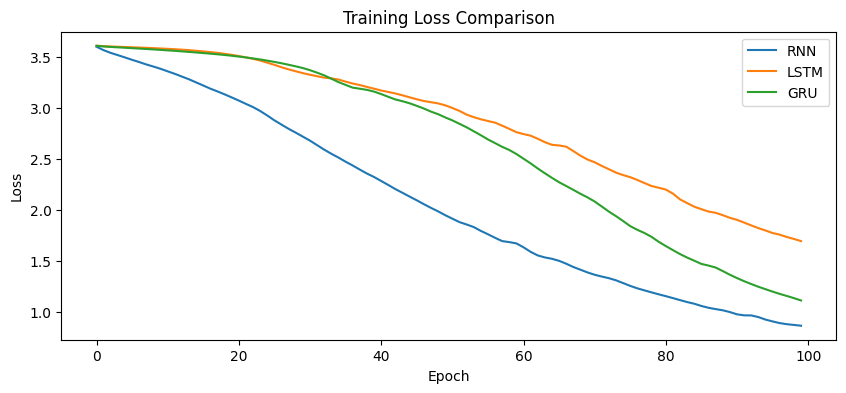

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [8]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [9]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning models can generate meaningful sentences
LSTM: deep learning learning can can meaningful meaningful
GRU : deep learning models can generate meaningful sentences


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

In [10]:
# Task 1 :
custom_corpus = '''
artificial intelligence is changing how we live and work every single day
machine learning models learn patterns directly from data instead of hardcoded rules
deep learning uses layered neural networks to model complex relationships in data
natural language processing helps computers understand and generate human language
recurrent networks are especially good at handling sequences like text and speech
with enough training data these models can write surprisingly coherent sentences
'''
custom_corpus = custom_corpus.lower().strip()
print(custom_corpus)

artificial intelligence is changing how we live and work every single day
machine learning models learn patterns directly from data instead of hardcoded rules
deep learning uses layered neural networks to model complex relationships in data
natural language processing helps computers understand and generate human language
recurrent networks are especially good at handling sequences like text and speech
with enough training data these models can write surprisingly coherent sentences


In [11]:
# Rebuild tokenizer + sequences on the custom corpus
custom_tokenizer = Tokenizer()
custom_tokenizer.fit_on_texts([custom_corpus])
custom_total_words = len(custom_tokenizer.word_index) + 1
print("Custom vocabulary size:", custom_total_words)

custom_sequences = []
for line in custom_corpus.split('\n'):
    token_list = custom_tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        custom_sequences.append(token_list[:i+1])

custom_max_len = max(len(seq) for seq in custom_sequences)
custom_sequences = pad_sequences(custom_sequences, maxlen=custom_max_len, padding='pre')

X2 = custom_sequences[:, :-1]
y2 = custom_sequences[:, -1]
print("X2 shape:", X2.shape, "| y2 shape:", y2.shape)

Custom vocabulary size: 62
X2 shape: (63, 11) | y2 shape: (63,)


In [12]:
# Tasks 2 & 4:
def build_upgraded_model(layer_cls, vocab_size, seq_len, units=128, embedding_dim=64):
    model = Sequential([
        Input(shape=(seq_len,)),
        Embedding(vocab_size, embedding_dim),
        layer_cls(units),
        Dense(vocab_size, activation='softmax')
    ])
    model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])
    return model

In [13]:
#Task 3 :
rnn_model_v2 = build_upgraded_model(SimpleRNN, custom_total_words, custom_max_len-1)
rnn_history_v2 = rnn_model_v2.fit(X2, y2, epochs=200, verbose=0)
print("Upgraded RNN training completed — final loss:", round(rnn_history_v2.history['loss'][-1], 4))

lstm_model_v2 = build_upgraded_model(LSTM, custom_total_words, custom_max_len-1)
lstm_history_v2 = lstm_model_v2.fit(X2, y2, epochs=200, verbose=0)
print("Upgraded LSTM training completed — final loss:", round(lstm_history_v2.history['loss'][-1], 4))

gru_model_v2 = build_upgraded_model(GRU, custom_total_words, custom_max_len-1)
gru_history_v2 = gru_model_v2.fit(X2, y2, epochs=200, verbose=0)
print("Upgraded GRU training completed — final loss:", round(gru_history_v2.history['loss'][-1], 4))

Upgraded RNN training completed — final loss: 0.0123
Upgraded LSTM training completed — final loss: 0.1263
Upgraded GRU training completed — final loss: 0.0187


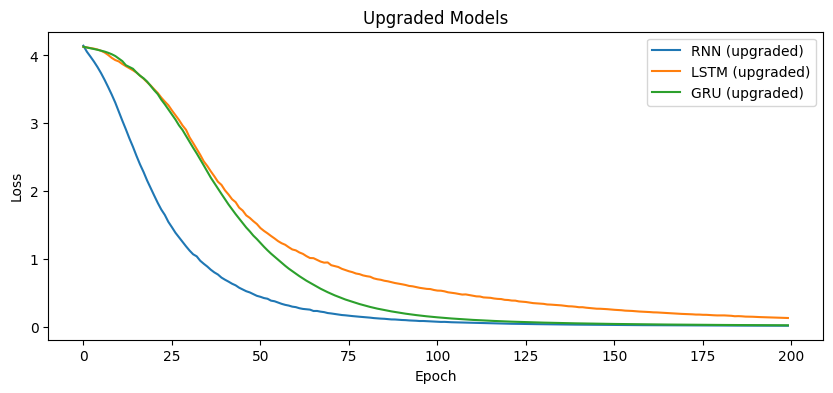

In [14]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history_v2.history['loss'], label='RNN (upgraded)')
plt.plot(lstm_history_v2.history['loss'], label='LSTM (upgraded)')
plt.plot(gru_history_v2.history['loss'], label='GRU (upgraded)')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Upgraded Models")
plt.legend()
plt.show()

In [15]:
# Task 5:
def generate_text_custom(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = custom_tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=custom_max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in custom_tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

seed2 = "artificial intelligence"
print("RNN (v2) :", generate_text_custom(rnn_model_v2, seed2, 10))
print("LSTM (v2):", generate_text_custom(lstm_model_v2, seed2, 10))
print("GRU (v2) :", generate_text_custom(gru_model_v2, seed2, 10))

RNN (v2) : artificial intelligence is changing how we live and work every single day
LSTM (v2): artificial intelligence is changing how we live and work every single day
GRU (v2) : artificial intelligence is changing how we live and work every single day


# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**